In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rm1000/lung-cancer-histopathological-images")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/lung-cancer-histopathological-images


In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import cv2
from sklearn.utils import shuffle
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from tqdm import trange
import torch.optim as optim
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
sns.set()

In [3]:
os.listdir("/kaggle/input/lung-cancer-histopathological-images")

['squamous_cell_carcinoma', 'benign', 'adenocarcinoma']

In [5]:
images, labels = [], []
for i in os.listdir("/kaggle/input/lung-cancer-histopathological-images"):
    for j in os.listdir(os.path.join("/kaggle/input/lung-cancer-histopathological-images", i)):
        path = os.path.join("/kaggle/input/lung-cancer-histopathological-images", i, j)
        img = cv2.imread(path)
        if img is None:
            print(path)
        else:
            images.append(img)
            labels.append(i)

In [5]:
print(f"Size of dataset: {len(images)}")
print(f"Number of classes: {len(set(labels))}")
print(f"Classes: {set(labels)}")

Size of dataset: 15000
Number of classes: 3
Classes: {'benign', 'squamous_cell_carcinoma', 'adenocarcinoma'}


In [8]:
X, y = shuffle(images, labels)

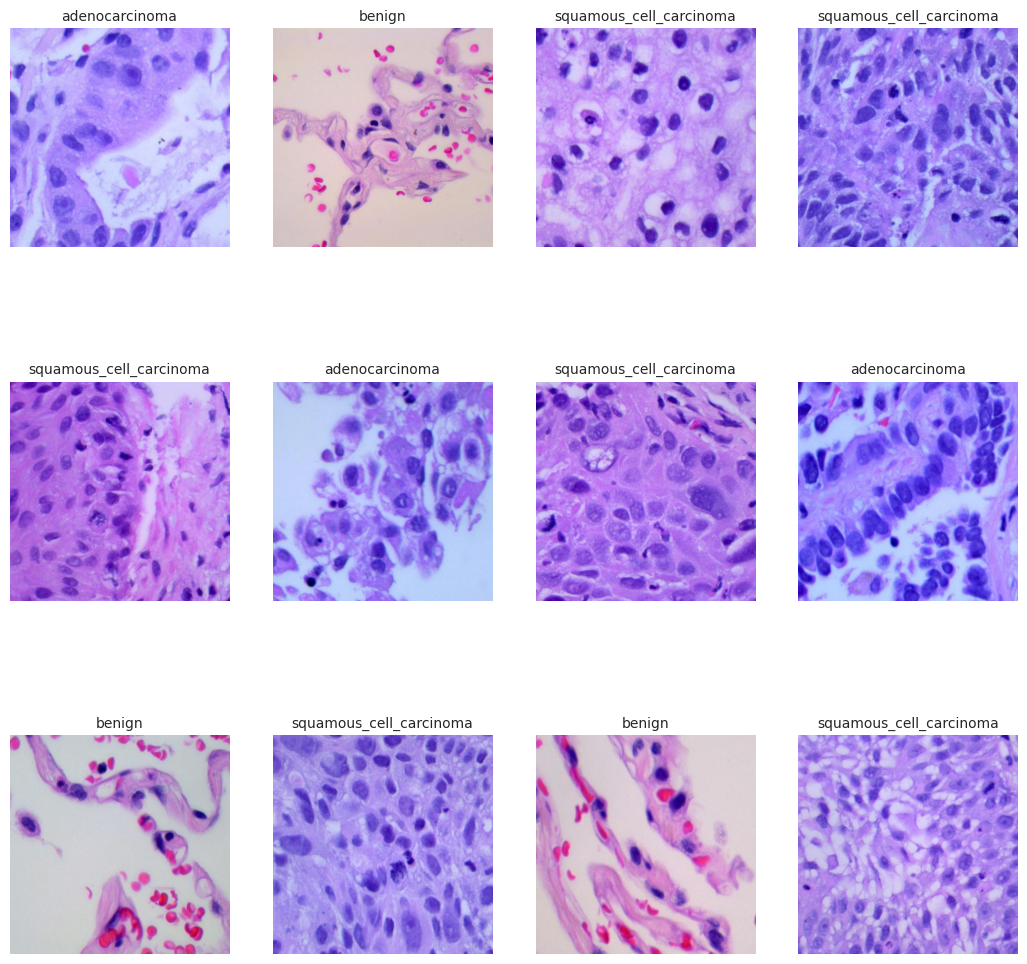

In [7]:
plt.figure(figsize = (13, 13))
for i in range(12):
    ax = plt.subplot(3, 4, i + 1)
    im = np.array(cv2.cvtColor(X[i], cv2.COLOR_BGR2RGB))
    plt.imshow(im)
    plt.title(y[i], fontsize = 10)
    plt.axis('off')

In [6]:
le = LabelEncoder()

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 101, stratify = y)

In [10]:
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size = 0.33, random_state = 101, stratify = y_test)

In [11]:
print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Validation set size: {len(X_val)}")

Training set size: 10500
Test set size: 3015
Validation set size: 1485


In [11]:
y_train_le = le.fit_transform(y_train)
y_test_le = le.transform(y_test)
y_val_le = le.transform(y_val)

In [12]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.5, 0.5, 0.5], std = [0.5, 0.5, 0.5])
])

In [13]:
class MyDataset(Dataset):
    def __init__(self, images, labels, transform = None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        if self.transform:
            image = Image.fromarray(image)
            image = self.transform(image)
        return image, label

In [14]:
train_dataset = MyDataset(X_train, y_train_le, transform = transform)
test_dataset = MyDataset(X_test, y_test_le, transform = transform)
val_dataset = MyDataset(X_val, y_val_le, transform = transform)

In [15]:
train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 64, shuffle = False)
val_loader = DataLoader(val_dataset, batch_size = 64, shuffle = False)

In [16]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [17]:
def plot_results(train_accs, train_losses, val_accs, val_losses):
    fig, axes = plt.subplots(1, 2, figsize = (15, 5))
    xs = np.arange(1, len(train_accs) + 1, 1)
    axes[0].plot(xs, train_accs, label = 'Training')
    axes[0].plot(xs, val_accs, label = 'Validation')
    axes[0].set_title('Training accuracy vs Validation accuracy', fontsize = 15)
    axes[0].set_xlabel('Epoch', fontsize = 10)
    axes[0].set_ylabel('Loss', fontsize = 10)
    axes[0].set_xticks(xs)
    axes[0].legend()
    axes[1].plot(xs, train_losses, label = 'Training')
    axes[1].plot(xs, val_losses, label = 'Validation')
    axes[1].set_title('Training loss vs Validation loss', fontsize = 15)
    axes[1].set_xlabel('Epoch', fontsize = 10)
    axes[1].set_ylabel('Accuracy', fontsize = 10)
    axes[1].set_xticks(xs)
    axes[1].legend()
    plt.tight_layout()
    plt.show()

In [18]:
def train_step(model, criterion, optimizer, dataloader, device = device):
    model.train()
    total_loss = 0
    total_acc = 0
    for batch in dataloader:
        x, y = batch
        x = x.to(device)
        y = y.to(device)
        optimizer.zero_grad()
        preds = model(x)
        loss = criterion(preds, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_acc += (preds.argmax(dim=1) == y).type(torch.float).sum().item()
    return total_loss / len(dataloader), 100 * total_acc / len(dataloader.dataset)

In [19]:
def val_step(model, criterion, dataloader, device = device):
    model.eval()
    total_loss = 0
    total_acc = 0
    with torch.no_grad():
        for batch in dataloader:
            x, y = batch
            x = x.to(device)
            y = y.to(device)
            preds = model(x)
            total_loss += criterion(preds, y).item()
            total_acc += (preds.argmax(dim=1) == y).type(torch.float).sum().item()
    return total_loss / len(dataloader), 100 * total_acc / len(dataloader.dataset)

In [20]:
def train_model(model, n_epochs, optimizer, train_loader, val_loader, device = device):
    train_accs, train_losses, val_accs, val_losses = [], [], [], []
    criterion = nn.CrossEntropyLoss()
    pbar = trange(n_epochs)
    for epoch in pbar:
        train_loss, train_acc = train_step(model, criterion, optimizer, train_loader, device)
        val_loss, val_acc = val_step(model, criterion, val_loader, device)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        pbar.set_description(f"Training Loss: {train_loss:.3f} | Validation Loss: {val_loss:.3f} | Training Accuracy: {train_acc:.3f} | Validation Accuracy: {val_acc:.3f}")
    plot_results(train_accs, train_losses, val_accs, val_losses)
    return{'train_acc': train_acc, 'train_loss': train_loss, 'val_acc': val_acc, 'val_loss': val_loss}

In [21]:
class conv_model1(nn.Module):
    def __init__(self, num_classes, input_size):
        super(conv_model1, self).__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels = 3, out_channels = 512, kernel_size = 3, stride = 1, padding = 1),
            nn.MaxPool2d(kernel_size = 2, stride = 2),
            nn.ReLU(),
            nn.Conv2d(in_channels = 512, out_channels = 256, kernel_size = 3, stride = 1, padding = 1),
            nn.MaxPool2d(kernel_size = 2, stride = 2),
            nn.ReLU(),
            nn.Conv2d(in_channels = 256, out_channels = 128, kernel_size = 3, stride = 1, padding = 1),
            nn.MaxPool2d(kernel_size = 2, stride = 2),
            nn.ReLU(),
            nn.Conv2d(in_channels = 128, out_channels = 64, kernel_size = 3, stride = 1, padding = 1),
            nn.MaxPool2d(kernel_size = 2, stride = 2),
            nn.ReLU(),
            nn.Conv2d(in_channels = 64, out_channels = 32, kernel_size = 3, stride = 1, padding = 1),
            nn.MaxPool2d(kernel_size = 2, stride = 2),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(4 * 4 * 32, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.network(x)

Training Loss: 0.070 | Validation Loss: 0.103 | Training Accuracy: 97.162 | Validation Accuracy: 96.498: 100%|██████████| 10/10 [17:30<00:00, 105.08s/it]


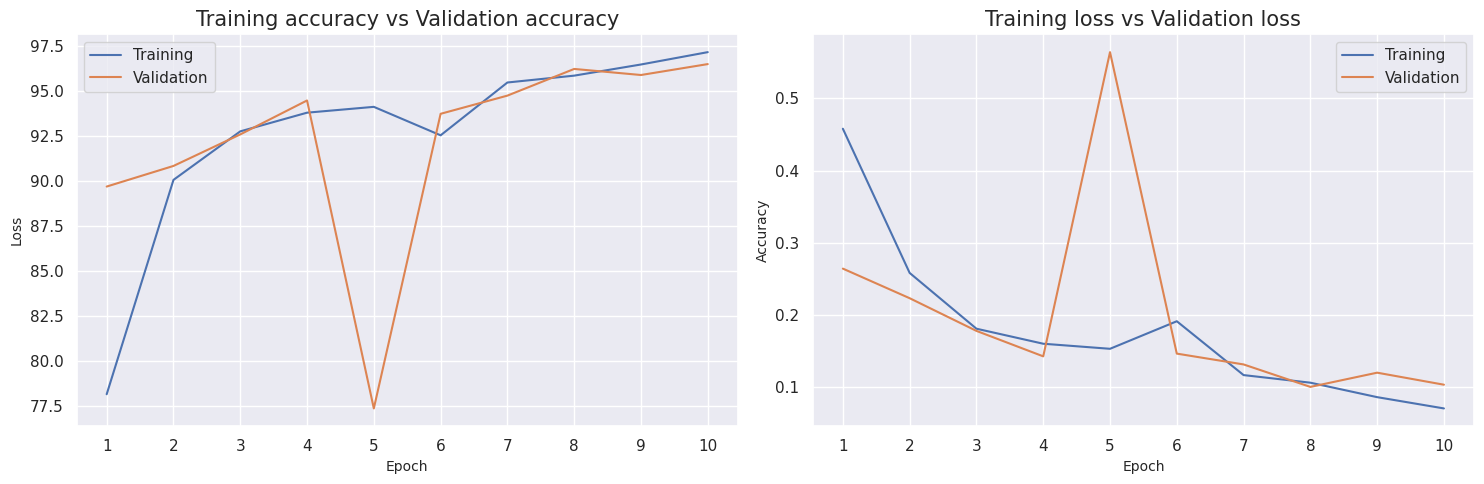

In [93]:
model1 = conv_model1(num_classes = 3, input_size = 128 * 128 * 3)
model1 = model1.to(device)
optimizer = optim.Adam(model1.parameters(), lr = 0.001)
results = train_model(model1, 10, optimizer, train_loader, val_loader, device = device)

In [95]:
class conv_model2(nn.Module):
    def __init__(self, num_classes, input_size):
        super(conv_model2, self).__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels = 3, out_channels = 512, kernel_size = 3, stride = 1, padding = 1),
            nn.MaxPool2d(kernel_size = 2, stride = 2),
            nn.ReLU(),
            nn.Dropout(0.50),
            nn.Conv2d(in_channels = 512, out_channels = 256, kernel_size = 3, stride = 1, padding = 1),
            nn.MaxPool2d(kernel_size = 2, stride = 2),
            nn.ReLU(),
            nn.Dropout(0.50),
            nn.Conv2d(in_channels = 256, out_channels = 128, kernel_size = 3, stride = 1, padding = 1),
            nn.MaxPool2d(kernel_size = 2, stride = 2),
            nn.ReLU(),
            nn.Dropout(0.50),
            nn.Conv2d(in_channels = 128, out_channels = 64, kernel_size = 3, stride = 1, padding = 1),
            nn.MaxPool2d(kernel_size = 2, stride = 2),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Conv2d(in_channels = 64, out_channels = 32, kernel_size = 3, stride = 1, padding = 1),
            nn.MaxPool2d(kernel_size = 2, stride = 2),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Flatten(),
            nn.Linear(4 * 4 * 32, 512),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.network(x)

Training Loss: 0.089 | Validation Loss: 0.091 | Training Accuracy: 96.448 | Validation Accuracy: 96.027: 100%|██████████| 10/10 [17:38<00:00, 105.81s/it]


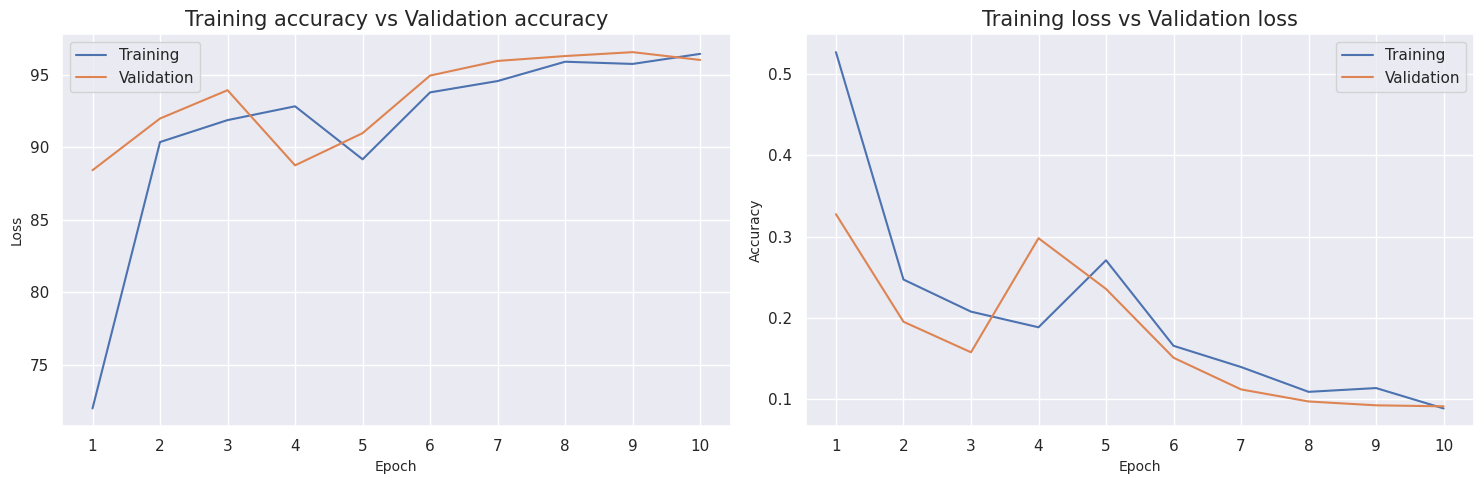

In [96]:
model2 = conv_model2(num_classes = 3, input_size = 128 * 128 * 3)
model2 = model2.to(device)
optimizer = optim.Adam(model2.parameters(), lr = 0.001)
results = train_model(model2, 10, optimizer, train_loader, val_loader, device = device)

In [98]:
class conv_model3(nn.Module):
    def __init__(self, num_classes, input_size):
        super(conv_model3, self).__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels = 3, out_channels = 512, kernel_size = 3, stride = 1, padding = 1),
            nn.MaxPool2d(kernel_size = 2, stride = 2),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(in_channels = 512, out_channels = 256, kernel_size = 3, stride = 1, padding = 1),
            nn.MaxPool2d(kernel_size = 2, stride = 2),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(in_channels = 256, out_channels = 128, kernel_size = 3, stride = 1, padding = 1),
            nn.MaxPool2d(kernel_size = 2, stride = 2),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(in_channels = 128, out_channels = 64, kernel_size = 3, stride = 1, padding = 1),
            nn.MaxPool2d(kernel_size = 2, stride = 2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(in_channels = 64, out_channels = 32, kernel_size = 3, stride = 1, padding = 1),
            nn.MaxPool2d(kernel_size = 2, stride = 2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(4 * 4 * 32, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.network(x)

Training Loss: 0.118 | Validation Loss: 0.176 | Training Accuracy: 95.781 | Validation Accuracy: 93.064: 100%|██████████| 10/10 [18:46<00:00, 112.66s/it]


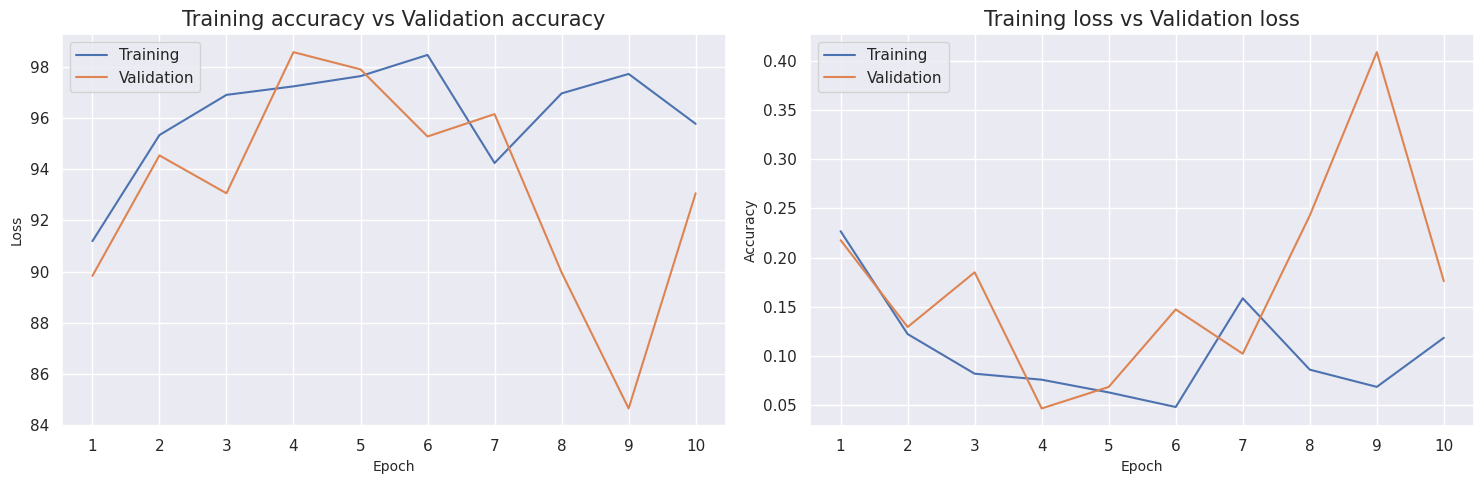

In [99]:
model3 = conv_model3(num_classes = 3, input_size = 128 * 128 * 3)
model3 = model3.to(device)
optimizer = optim.Adam(model3.parameters(), lr = 0.001)
results = train_model(model3, 10, optimizer, train_loader, val_loader, device = device)

In [22]:
class conv_model4(nn.Module):
    def __init__(self, num_classes, input_size):
        super(conv_model4, self).__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels = 3, out_channels = 512, kernel_size = 3, stride = 1, padding = 1),
            nn.MaxPool2d(kernel_size = 2, stride = 2),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Dropout(0.50),
            nn.Conv2d(in_channels = 512, out_channels = 256, kernel_size = 3, stride = 1, padding = 1),
            nn.MaxPool2d(kernel_size = 2, stride = 2),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout(0.50),
            nn.Conv2d(in_channels = 256, out_channels = 128, kernel_size = 3, stride = 1, padding = 1),
            nn.MaxPool2d(kernel_size = 2, stride = 2),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout(0.50),
            nn.Conv2d(in_channels = 128, out_channels = 64, kernel_size = 3, stride = 1, padding = 1),
            nn.MaxPool2d(kernel_size = 2, stride = 2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Conv2d(in_channels = 64, out_channels = 32, kernel_size = 3, stride = 1, padding = 1),
            nn.MaxPool2d(kernel_size = 2, stride = 2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Flatten(),
            nn.Linear(4 * 4 * 32, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.network(x)

Training Loss: 0.159 | Validation Loss: 0.042 | Training Accuracy: 94.943 | Validation Accuracy: 98.384: 100%|██████████| 20/20 [36:12<00:00, 108.63s/it]


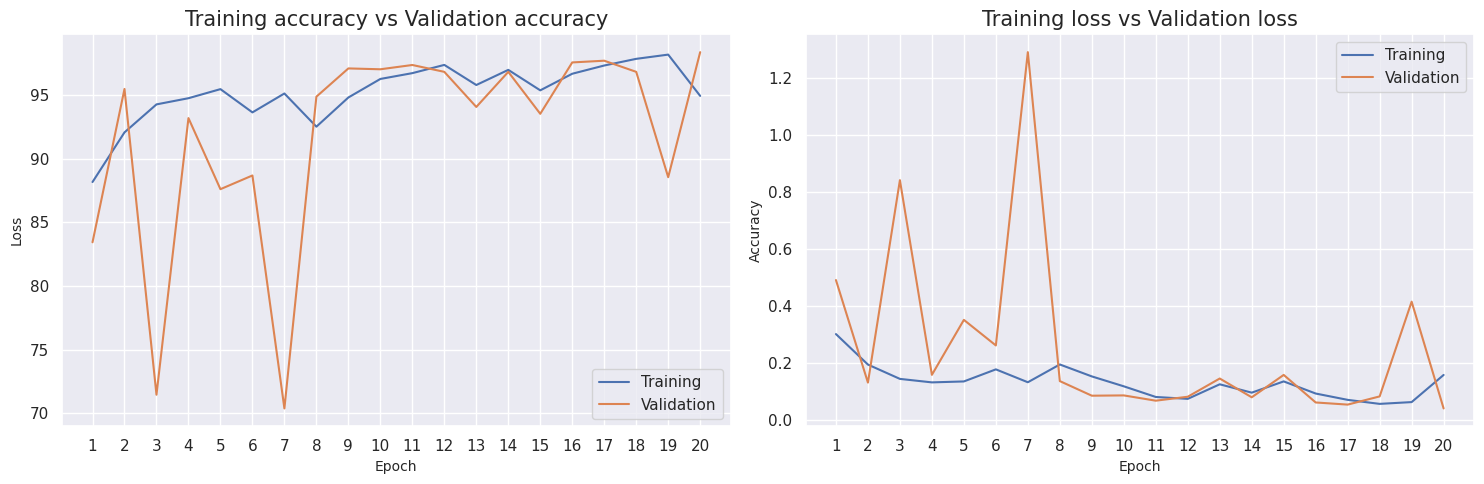

In [23]:
model4 = conv_model4(num_classes = 3, input_size = 128 * 128 * 3)
model4 = model4.to(device)
optimizer = optim.Adam(model4.parameters(), lr = 0.001)
results = train_model(model4, 20, optimizer, train_loader, val_loader, device = device)

In [24]:
criterion = nn.CrossEntropyLoss()
test_loss, test_acc = val_step(model4, criterion, test_loader, device = device)

In [25]:
print(f"Test Loss: {test_loss:.3f} | Test Accuracy: {test_acc:.3f}")

Test Loss: 0.049 | Test Accuracy: 98.176


In [27]:
predicted = []
labels = []
model4.eval()
with torch.no_grad():
    for batch in test_loader:
        x, y = batch
        x = x.to(device)
        y = y.to(device)
        probs = model4(x)
        preds = probs.argmax(dim=1)
        predicted.append(preds)
        labels.append(y)

In [30]:
predicted[:10]

[tensor([0, 2, 0, 2, 0, 2, 1, 0, 2, 0, 2, 0, 0, 2, 0, 2, 1, 1, 0, 2, 2, 2, 1, 2,
         2, 2, 1, 2, 0, 2, 2, 1, 1, 0, 2, 1, 0, 0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 2,
         0, 0, 0, 0, 2, 2, 1, 1, 1, 0, 0, 2, 1, 2, 1, 0], device='cuda:0'),
 tensor([0, 0, 2, 1, 2, 1, 2, 2, 1, 2, 1, 0, 2, 1, 1, 2, 2, 2, 0, 1, 0, 1, 0, 1,
         0, 0, 0, 2, 0, 0, 2, 2, 0, 1, 0, 0, 1, 2, 1, 1, 2, 0, 1, 1, 0, 0, 0, 2,
         0, 2, 2, 2, 1, 1, 2, 1, 0, 2, 2, 0, 2, 2, 0, 2], device='cuda:0'),
 tensor([0, 1, 0, 1, 0, 0, 2, 1, 0, 0, 2, 1, 1, 0, 1, 0, 2, 2, 0, 1, 1, 0, 0, 0,
         0, 0, 0, 2, 2, 1, 0, 2, 1, 0, 1, 0, 0, 2, 2, 0, 1, 0, 2, 0, 2, 2, 1, 1,
         0, 0, 1, 0, 2, 2, 2, 1, 1, 1, 1, 0, 2, 0, 2, 2], device='cuda:0'),
 tensor([1, 1, 1, 0, 0, 1, 1, 0, 2, 1, 2, 1, 1, 2, 0, 2, 1, 0, 1, 2, 0, 2, 2, 2,
         0, 1, 0, 1, 2, 1, 0, 0, 1, 2, 1, 2, 1, 0, 2, 0, 1, 0, 0, 0, 0, 2, 1, 0,
         0, 2, 1, 2, 2, 0, 1, 0, 0, 1, 2, 1, 2, 2, 2, 1], device='cuda:0'),
 tensor([0, 2, 2, 0, 1, 0, 2, 0, 1, 2, 0, 0, 1, 

In [31]:
predicted2 = np.concatenate([t.cpu().numpy() for t in predicted])
labels2 = np.concatenate([t.cpu().numpy() for t in labels])

In [35]:
print(classification_report(labels2, predicted2))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1005
           1       1.00      1.00      1.00      1005
           2       0.97      0.98      0.97      1005

    accuracy                           0.98      3015
   macro avg       0.98      0.98      0.98      3015
weighted avg       0.98      0.98      0.98      3015



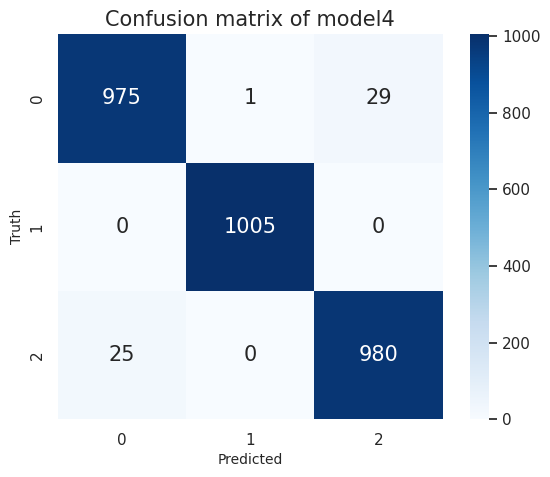

In [37]:
plt.figure(figsize = (7, 5))
sns.heatmap(confusion_matrix(labels2, predicted2), annot = True, square = True, cbar = True, annot_kws = {'size': 15}, fmt = 'd', cmap = 'Blues')
plt.title('Confusion matrix of model4', fontsize = 15)
plt.xlabel('Predicted', fontsize = 10)
plt.ylabel('Truth', fontsize = 10)
plt.show()